In [65]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import src.preference_factors.build_datasets as bd
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


In [4]:
def build_official_market_series(ff_factors_file: str, frequency="monthly", excess = False):
    ff = bd.build_ff_dataset(ff_factors_file, frequency)

    # MKT = (MKT-RF) + RF
    if excess:
        market = ff["MKT_RF"]
    else:
        market = ff["MKT_RF"] + ff["RF"]

    market = market.to_frame("Official_Market")

    return market

In [66]:
def plot_cum_log_returns(df, column_names):

    # Ensure list
    if isinstance(column_names, str):
        column_names = [column_names]

    df = df.copy()

    # Fix index
    if isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.to_timestamp(how="end")
    else:
        df.index = pd.to_datetime(df.index)

    # Select columns and force numeric
    data = df[column_names].apply(pd.to_numeric, errors="coerce")

    # Drop rows where all are NaN
    data = data.dropna(how="all")

    # Compute cumulative log returns
    log_ret = np.log1p(data)
    cum_log = log_ret.cumsum()

    # Plot
    plt.figure(figsize=(10,6))

    for col in column_names:
        plt.plot(cum_log.index, cum_log[col], label=col)

    plt.title("Cumulative Log Returns")
    plt.ylabel("Cumulative Log Return")
    plt.xlabel("Date")
    plt.legend()
    plt.show()

    return cum_log

In [6]:
def compute_return_stats(series, frequency="monthly"):
    arith_mean = series.mean()

    geom_mean = np.exp(np.log1p(series).mean()) - 1

    if frequency == "monthly":
        ann_factor = 12
    else:
        ann_factor = 252

    stats = {
        "Arithmetic Mean": arith_mean,
        "Arithmetic Annualized": arith_mean * ann_factor,
        "Geometric Mean": geom_mean,
        "Geometric Annualized": (1 + geom_mean)**ann_factor - 1
    }

    return pd.Series(stats)

# Official coming straight from ff factors files

In [68]:
official = build_official_market_series("ff_factors_monthly.csv", "monthly")

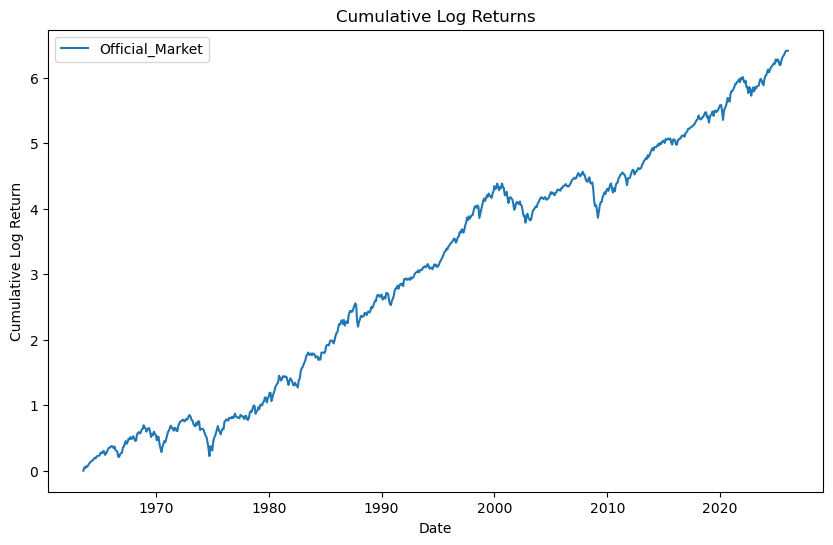

,Official_Market
date,
1963-07-31 23:59:59.999999999,-0.001201
1963-08-31 23:59:59.999999999,0.050727
1963-09-30 23:59:59.999999999,0.037642
1963-10-31 23:59:59.999999999,0.065549
1963-11-30 23:59:59.999999999,0.059632
...,...
2025-08-31 23:59:59.999999999,6.347881
2025-09-30 23:59:59.999999999,6.384406
2025-10-31 23:59:59.999999999,6.407439


In [70]:
plot_cum_log_returns(official, ["Official_Market"])


In [9]:
compute_return_stats(official["Official_Market"])

Arithmetic Mean          0.009578
Arithmetic Annualized    0.114931
Geometric Mean           0.008582
Geometric Annualized     0.107985
dtype: float64

# Read existing files

In [10]:
project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))


DATA_PROCESSED_DIR = project_root / "data" / "processed"

In [11]:
## get CW from our build
monthly_dir = DATA_PROCESSED_DIR / 'monthly'
df_monthly = pd.read_csv(
    monthly_dir / "monthly_preference_excess_returns_and_factors.csv",
    index_col=0,
    parse_dates=True
)

In [12]:
df_monthly["CW"]

date
1963-07-01   -0.003284
1963-08-01    0.052482
1963-09-01   -0.011536
1963-10-01    0.035815
1963-11-01   -0.005499
                ...   
2024-08-01    0.023316
2024-09-01    0.021856
2024-10-01   -0.008686
2024-11-01    0.062461
2024-12-01   -0.018849
Name: CW, Length: 738, dtype: float64

In [13]:
compute_return_stats(df_monthly["CW"])

Arithmetic Mean          0.010341
Arithmetic Annualized    0.124087
Geometric Mean           0.009410
Geometric Annualized     0.118958
dtype: float64

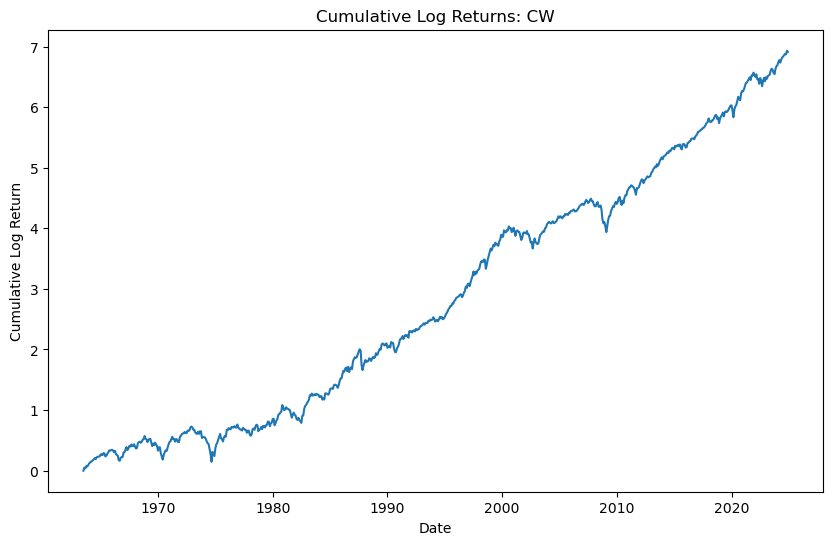

date
1963-07-01   -0.003289
1963-08-01    0.047862
1963-09-01    0.036259
1963-10-01    0.071448
1963-11-01    0.065934
                ...   
2024-08-01    6.857988
2024-09-01    6.879609
2024-10-01    6.870885
2024-11-01    6.931473
2024-12-01    6.912444
Name: CW, Length: 738, dtype: float64

In [14]:
plot_cum_log_returns(df_monthly,"CW")

# New function only with CW and EW

In [20]:
merged, full = bd.build_cw_ew_dataset("sp500_returns_monthly_with_tickers.csv",
                                      "sp500_market_caps_monthly.csv",
                                      "ff_factors_monthly.csv")

In [22]:
compute_return_stats(merged["CW"])

Arithmetic Mean          0.008240
Arithmetic Annualized    0.098877
Geometric Mean           0.007171
Geometric Annualized     0.089529
dtype: float64

In [73]:
full["MKT"] = full["MKT_RF"] + full["RF"]
full["CW_RF"] = full["CW"] - full["RF"]

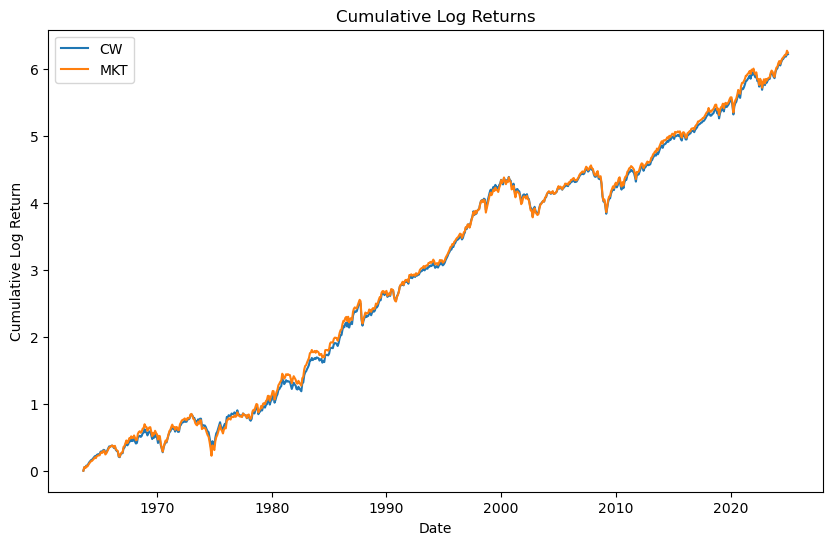

,CW,MKT
date,,
1963-07-31 23:59:59.999999999,-0.001823,-0.001201
1963-08-31 23:59:59.999999999,0.050247,0.050727
1963-09-30 23:59:59.999999999,0.039789,0.037642
1963-10-31 23:59:59.999999999,0.073990,0.065549
1963-11-30 23:59:59.999999999,0.069492,0.059632
...,...,...
2024-08-31 23:59:59.999999999,6.174914,6.193728
2024-09-30 23:59:59.999999999,6.197245,6.214804
2024-10-31 23:59:59.999999999,6.188517,6.208686


In [72]:
plot_cum_log_returns(full,["CW","MKT"])

In [75]:
compute_return_stats(full["MKT"])

Arithmetic Mean          0.009504
Arithmetic Annualized    0.114049
Geometric Mean           0.008501
Geometric Annualized     0.106918
dtype: float64

In [76]:
compute_return_stats(full["CW"])

Arithmetic Mean          0.009401
Arithmetic Annualized    0.112811
Geometric Mean           0.008468
Geometric Annualized     0.106490
dtype: float64

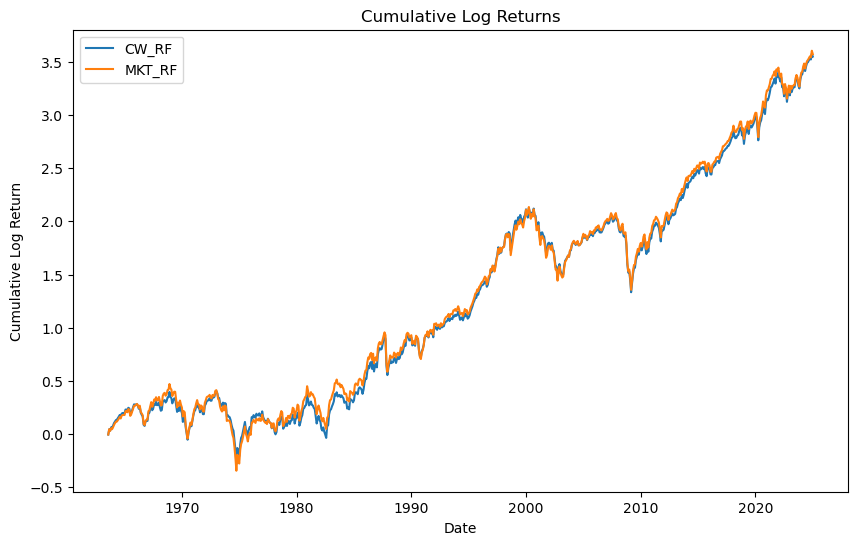

,CW_RF,MKT_RF
date,,
1963-07-31 23:59:59.999999999,-0.004532,-0.003908
1963-08-31 23:59:59.999999999,0.045163,0.045644
1963-09-30 23:59:59.999999999,0.031972,0.029820
1963-10-31 23:59:59.999999999,0.063367,0.054902
1963-11-30 23:59:59.999999999,0.056153,0.046265
...,...,...
2024-08-31 23:59:59.999999999,3.516794,3.534861
2024-09-30 23:59:59.999999999,3.535207,3.552013
2024-10-31 23:59:59.999999999,3.522536,3.541962


In [74]:
plot_cum_log_returns(full,["CW_RF","MKT_RF"])

In [77]:
compute_return_stats(full["CW_RF"])


Arithmetic Mean          0.005764
Arithmetic Annualized    0.069162
Geometric Mean           0.004822
Geometric Annualized     0.059418
dtype: float64

In [78]:
compute_return_stats(full["MKT_RF"])

Arithmetic Mean          0.005867
Arithmetic Annualized    0.070400
Geometric Mean           0.004853
Geometric Annualized     0.059816
dtype: float64